In [ ]:
!pip install bertopic

In [ ]:
from google.colab import drive
drive.mount("/content/gdrive")
import pandas as pd
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from bertopic.representation import MaximalMarginalRelevance
from wordcloud import WordCloud
import matplotlib.pyplot as plt

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
# read in the preprocessed dataframe, save the corpus as a list
df = pd.read_csv("/content/gdrive/MyDrive/NaturalLanguageProcessing/apple_text_preprocessed.csv")
corpus = list(df["corpus"])
corpus[:2]

["Dont buy these The only good thing about these headphones is the delivery time as it came three or four days after ordering. They sound okay but if they get too loud it just hurts your ears. Besides that the plastic is cheap and along with them hurting your ears when the musics up higher nafter about twenty minutes don't want to wear them. Oh and did I mention the right one didn't  work right out of the box.",
 "I suppose... These headphones came pretty quick. I can say they have great service. I thought these would be like the ones you get from an iPod. They feel weird but I guess they'll do for now. It was somewhat worth it."]

# Creating the embeddings and running the BERTopic algorithm

In [ ]:
# Using pre-trained BERT model to generate documnet-word embeddings
sentence_model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = sentence_model.encode(corpus, show_progress_bar=True)

Batches:   0%|          | 0/1588 [00:00<?, ?it/s]

In [ ]:
# Dimensionality Reduction: UMAP Parameters
umap_model = UMAP(n_neighbors=15, # size of the local neighborhood looked at when attempting to learn the structure of the data
                  n_components=10, # dimensionality of the reduced dimension space
                  metric='cosine', # how distance is computed in the space of the input data
                  low_memory=False)

# Density Clustering: HDBSCAN Parameters
hdbscan_model = HDBSCAN(min_cluster_size=150, # minimum size of identified clusters
                        min_samples=35, # minimum number of neighbours to a core point
                        metric='euclidean', # how distance is computed between points
                        prediction_data=False) # if set to true, can allow for new predictions later (not needed)

# Train BERTopic with a custom CountVectorizer
vectorizer_model = CountVectorizer(min_df=10) 
# integer representing how frequent a word must be before being added to representation 
# -> prevent a huge vocabulary, can set the min_df to only accept words that have a minimum frequency

# many words that are very similar / essentially mean the same thing - limit the number of duplicate words we find in each topic
representation_model = MaximalMarginalRelevance(diversity=0.3)

# Train BERTopic with the parameters specified above
topic_model = BERTopic(representation_model=representation_model, 
                       umap_model=umap_model, 
                       hdbscan_model=hdbscan_model, 
                       vectorizer_model=vectorizer_model,
                       min_topic_size = 100, # default: 10
                       nr_topics = 30).fit(corpus, embeddings) # decreasing it forces a lot of datapoints into one category
                       # for a fine-grained analysis, you want a lot of topics

# Fine-tune topic representations after training BERTopic
vectorizer_model = CountVectorizer(stop_words="english", ngram_range=(1, 2), min_df=10) # allow for 2 word presentations
topic_model.update_topics(corpus, vectorizer_model=vectorizer_model)

# Titles of the identified topics and count of reviews

In [ ]:
topic_model.get_topic_info()

,Topic,Count,Name
0,-1,19534,-1_phone_iphone_new_great
1,0,10389,0_great_product_good_works
2,1,3254,1_refurbished_screen_phone_buy
3,2,3100,2_case_fit_clip_fits
4,3,1931,3_iphone_6s_plus_4s
5,4,1370,4_scratches_scratch_phone_new
6,5,1367,5_apple_ipad_adapter_power
7,6,1093,6_watch_apple_band_love
8,7,1091,7_battery_charge_hold charge_hold
9,8,1025,8_unlocked_locked_unlock_phone unlocked


# Most relevant words for the first 4 topics

In [ ]:
topic_model.get_topic(0)

[('great', 0.04520537553993112),
 ('product', 0.03656681820183149),
 ('good', 0.03365897856918196),
 ('works', 0.031860350851103204),
 ('fast', 0.023793867942555384),
 ('happy', 0.022397045773852462),
 ('perfect', 0.022377486549196517),
 ('love', 0.02142027317234237),
 ('described', 0.02131031348760856),
 ('thank', 0.020769555681523947)]

In [ ]:
topic_model.get_topic(1)

[('refurbished', 0.045343230720152665),
 ('screen', 0.03541051753007383),
 ('phone', 0.033379536189218614),
 ('buy', 0.01910908467640214),
 ('new', 0.018289581439276986),
 ('working', 0.01794703139524029),
 ('work', 0.017704468643820397),
 ('refurbished phone', 0.017085501950697808),
 ('months', 0.016976818101027937),
 ('apple', 0.016217154026829852)]

In [ ]:
topic_model.get_topic(2)

[('case', 0.12403878199037646),
 ('fit', 0.03463986731909283),
 ('clip', 0.03053406519526846),
 ('fits', 0.030196414756183204),
 ('cover', 0.027757272348752547),
 ('iphone', 0.027181673834009525),
 ('cases', 0.02207376066945574),
 ('color', 0.021458899292573327),
 ('nice', 0.020900978573597895),
 ('great', 0.01980432698329575)]

In [ ]:
topic_model.get_topic(3)

[('iphone', 0.056283858268719344),
 ('6s', 0.034308965211321416),
 ('plus', 0.025114188379204913),
 ('4s', 0.023712903285028907),
 ('iphone 6s', 0.02328401481777256),
 ('phone', 0.020704013259209206),
 ('love', 0.018899796037498123),
 ('5s', 0.018822078045106817),
 ('apple', 0.017125411748541885),
 ('better', 0.015715978628031233)]

# Visualization of the topics on a 2D plane

In [ ]:
topic_model.visualize_topics()

# Visualization of the review embeddings in 2D space

In [ ]:
 # Run the visualization with the original embeddings
topic_model.visualize_documents(corpus, embeddings=embeddings, hide_annotations=True)

Output hidden; open in https://colab.research.google.com to view.

# Receive the reviews' mappings to the topics

In [ ]:
topics, probs = topic_model.fit_transform(corpus)
df_topics = pd.DataFrame({'topic': topics, 'document': corpus})

In [ ]:
df_topics.head()

,topic,document
0,12,Dont buy these The only good thing about these...
1,13,I suppose... These headphones came pretty quic...
2,12,Awesome! I was replacing my earbuds and was re...
3,12,iPod headphones They are pretty good. I would ...
4,1,Fits Like a Glove... on OJ Simpson's Hand Thes...


# Create word clouds for the first 10 topics

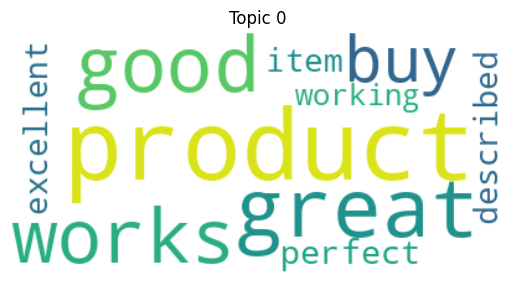

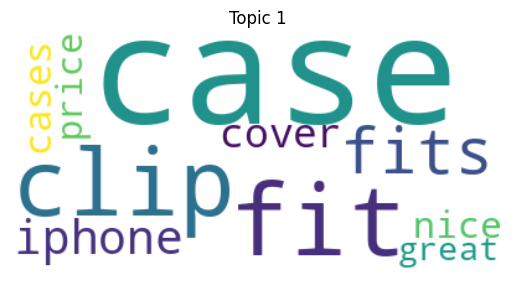

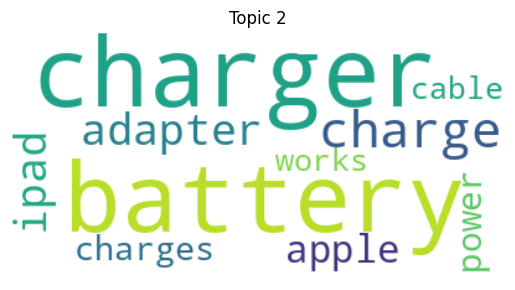

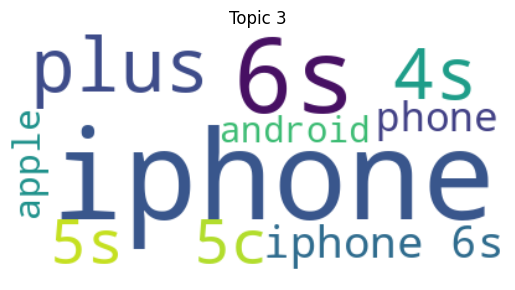

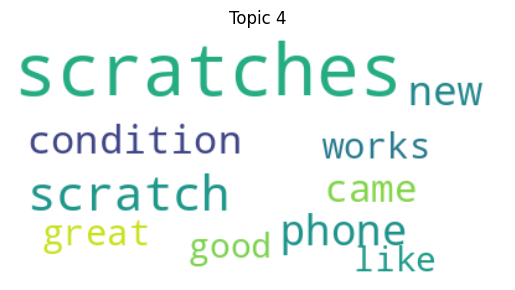

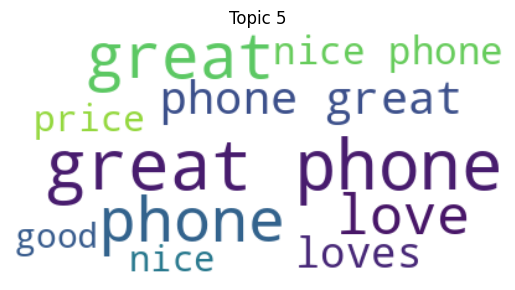

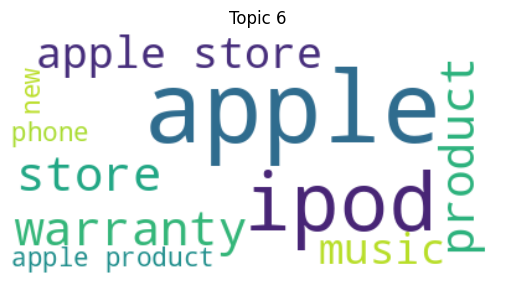

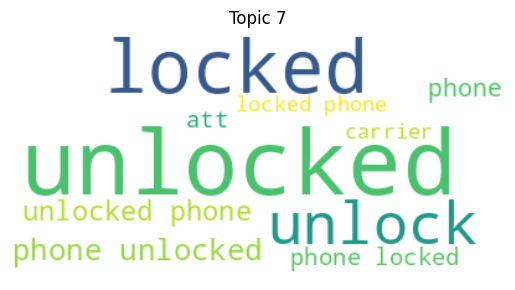

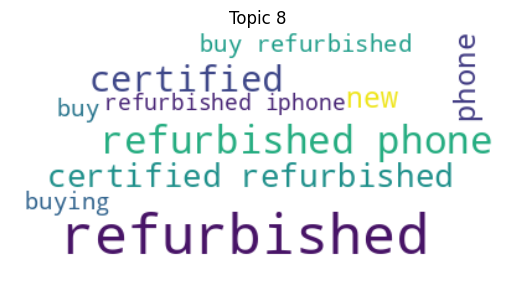

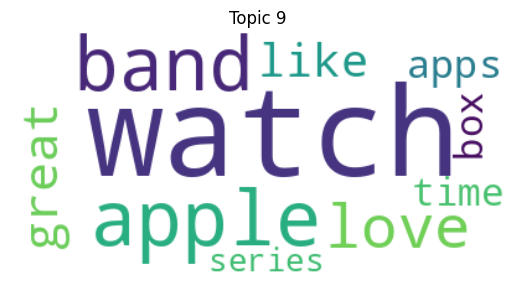

In [ ]:
def create_wordcloud(topic_model, topic):
    text = {word: value for word, value in topic_model.get_topic(topic)}
    wc = WordCloud(background_color="white", max_words=1000)
    wc.generate_from_frequencies(text)
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Topic {topic}")
    plt.show()

# Show word cloud
for i in range(10):
  create_wordcloud(topic_model, topic=i)

# Visualizing the contribution of the most influential words per topic

In [ ]:
topic_model.visualize_barchart()

# Analyzing the label distribution for the ten largest topics

In [ ]:
classes = list(df["overall"])
topics_per_class = topic_model.topics_per_class(corpus, classes=classes)
topic_model.visualize_topics_per_class(topics_per_class)